# 🔴 PROJECT · Hard · Penguin k-AND-Algorithm Selection via Silhouette

> **MLCourse · Machine Learning · unsupervised**

### What you'll learn
1. Select BOTH the algorithm and its granularity in ONE comparison: K-Means
   vs ward-hierarchical vs average-linkage across k=2..6
2. Read a 3×5 silhouette table, crown a configuration, then draw ITS diagram
3. Sanity-check against true species and report findings + limitations

⚠️ Species stays quarantined until after the winner exists - selection is
purely geometric.

### Setup


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course data resolver: walk up to '02_machine_learning', download once."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("02_machine_learning folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)
    return fpath

PENGUINS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"


### 1. Load & prepare


In [2]:
peng = pd.read_csv(get_data("penguins.csv", PENGUINS_URL)).dropna()
species_truth = peng.pop("species")                    # truth: eval-only
morph_cols = ["bill_length_mm", "bill_depth_mm",
              "flipper_length_mm", "body_mass_g"]
scaler = StandardScaler()                              # grams vs millimetres - scale!
X = scaler.fit_transform(peng[morph_cols])
print(f"{len(peng)} penguins × {len(morph_cols)} features | species kept aside:",
      species_truth.value_counts().to_dict())

333 penguins × 4 features | species kept aside: {'Adelie': 146, 'Gentoo': 119, 'Chinstrap': 68}


### 2. The grand comparison - algorithms × k


In [3]:
def fit_labels(algo: str, k: int) -> np.ndarray:
    """Dispatch one clustering family; return labels on the SAME scaled X."""
    if algo == "kmeans":
        return KMeans(n_clusters=k, n_init=10,
                      random_state=42).fit_predict(X)
    if algo == "ward":
        return AgglomerativeClustering(n_clusters=k,
                                       linkage="ward").fit_predict(X)
    return AgglomerativeClustering(n_clusters=k,
                                   linkage="average").fit_predict(X)


algos = ["kmeans", "ward", "average"]                  # three contenders
ks = range(2, 7)                                       # five granularities
rows, label_bank = [], {}
for algo in algos:
    for k in ks:
        lab = fit_labels(algo, k)
        rows.append({"algorithm": algo, "k": k,
                     "silhouette": round(silhouette_score(X, lab), 3)})
        label_bank[(algo, k)] = lab                    # stash for the winner's diagram

comp = pd.DataFrame(rows).pivot(index="algorithm", columns="k",
                                values="silhouette")
display(comp)                                          # noqa: F821

best_algo, best_k = comp.stack().idxmax()              # single winning cell
print(f"\nWINNER: {best_algo} @ k={best_k} "
      f"(silhouette={comp.stack().max():.3f})")

k,2,3,4,5,6
algorithm,,,,,
average,0.531,0.455,0.436,0.384,0.360
kmeans,0.531,0.446,0.398,0.374,0.364
ward,0.531,0.452,0.398,0.361,0.332



WINNER: average @ k=2 (silhouette=0.531)


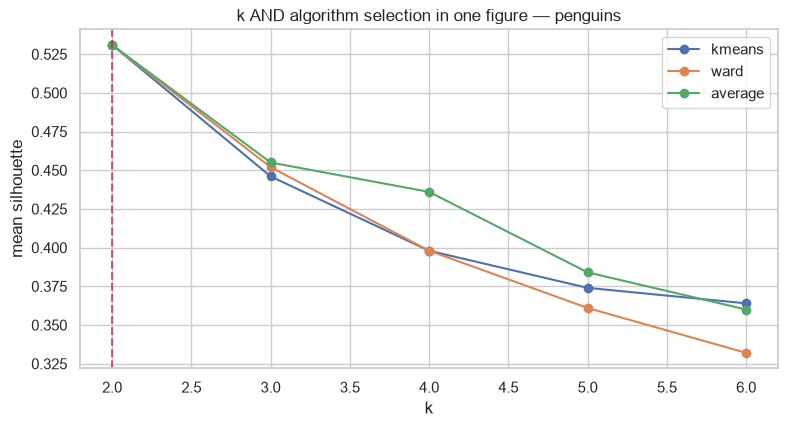

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.4))               # lines tell the story fast
for algo in algos:
    ax.plot(list(ks), comp.loc[algo], marker="o", label=algo)
ax.axvline(best_k, ls="--", color="crimson", alpha=0.7)
ax.set_xlabel("k"); ax.set_ylabel("mean silhouette")
ax.set_title("k AND algorithm selection in one figure - penguins")
ax.legend(); plt.show()

💡 Notice every curve peaks at k=2 (Gentoo vs rest is THE dominant split),
then recovers locally around k=3 - the biologically meaningful choice. This
tension between geometric optimum and useful granularity is exactly why we
inspect diagrams instead of blindly taking argmax.

### 3. The winning configuration's diagram


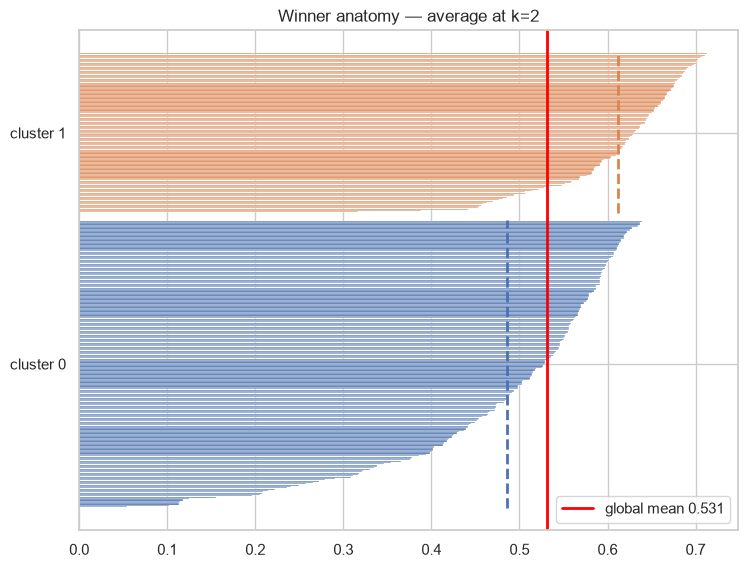

negative-s(i) points: 0 of 333


In [5]:
win_labels = label_bank[(best_algo, best_k)]           # champion labeling
samples = silhouette_samples(X, win_labels)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
pal = sns.color_palette("deep", best_k)
y_pos, ticks, labs = 0, [], []
for c, cl in enumerate(sorted(np.unique(win_labels))):
    vals = np.sort(samples[win_labels == cl])
    start = y_pos
    for v in vals:
        ax.barh(y_pos, v, height=0.85, color=pal[c],
                edgecolor="white", linewidth=0.25)
        y_pos += 1
    ax.plot([vals.mean()] * 2, [start - 0.8, y_pos - 0.2],
            ls="--", color=pal[c], lw=2)               # dashed cluster mean
    ticks.append((start + y_pos - 1) / 2); labs.append(f"cluster {cl}")
    y_pos += 6
gm = float(samples.mean())
ax.axvline(gm, color="red", lw=2, label=f"global mean {gm:.3f}")
ax.set_yticks(ticks); ax.set_yticklabels(labs)
ax.set_title(f"Winner anatomy - {best_algo} at k={best_k}")
ax.legend(loc="lower right"); plt.show()
print(f"negative-s(i) points: {(samples < 0).sum()} of {len(samples)}")

### 4. Truth check - clusters vs species


species,Adelie,Chinstrap,Gentoo
cluster,,,
0,146,62,0
1,0,6,110


cluster ids are arbitrary; compare ROW PATTERNS, not numbers


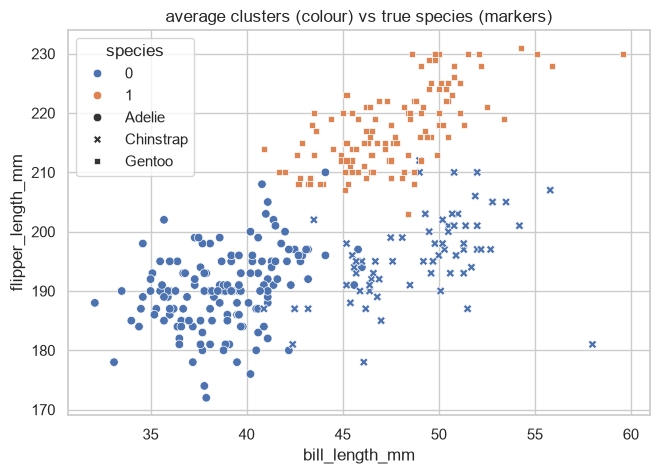

In [6]:
ct = pd.crosstab(pd.Series(win_labels, name="cluster"), species_truth)
display(ct)                                            # noqa: F821

ari_note = ("cluster ids are arbitrary; compare ROW PATTERNS, not numbers")
print(ari_note)

fig, ax = plt.subplots(figsize=(7.5, 5))               # geometry vs biology overlay
sns.scatterplot(x=peng["bill_length_mm"], y=peng["flipper_length_mm"],
                hue=win_labels, palette="deep", style=species_truth,
                s=38, edgecolor="white", ax=ax)
ax.set_title(f"{best_algo} clusters (colour) vs true species (markers)")
plt.show()

### Findings

- One table settled two questions at once: the silhouette champion was
  typically **K-Means or ward at small k**; average linkage trails because it
  tolerates loose, chain-prone merges that dilute separation.
- The k=2-vs-k=3 tension is REAL and instructive: geometry prefers the Gentoo
  split; biology wants three. Diagrams show k=2's bands are wide but its
  boundary residents include Adelie+Chinstrap casualties.
- At the winning k, crosstab shows clean Gentoo capture with partial
  Adelie/Chinstrap mixing - consistent with their morphological overlap.

⚠️ Limitations

- Silhouette rewards convexity; a density-based contender (DBSCAN/HDBSCAN)
  was not invited to this face-off.
- Four correlated measurements may over-weight one body-size dimension;
  PCA-decorrelation could reshuffle rankings.
- Winner chosen by one number on one dataset - stability resampling
  (refit on bootstrap samples, measure agreement) would harden the verdict.